# import package

In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import pandas as pd
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score
import argparse
import logging
import itertools
import contextlib
import io

# import data

In [2]:
df_org = pd.read_csv("C:/Users/ASUS/Desktop/cg working/Variational autoencoder/vae_compare/data15000_nclass.csv")
df = df_org.drop(columns=["Unnamed: 0","propensity0","propensity1","propensity2","propensity3"])
df_train_all, df_test = train_test_split(df,test_size=0.2,train_size=0.8,random_state=62619,shuffle=True)
df_train, df_valid = train_test_split(df_train_all,test_size=0.2,train_size=0.8,random_state=62619,shuffle=True)
feature_cols = [f'X{j}' for j in range(1, 16)]

In [3]:
df

,outcome,ite1,ite2,ite3,Treat_0,Treat_1,Treat_2,Treat_3,X1,X2,...,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15
0,6.918691,2.914008,4.010017,-2.420075,0,1,0,0,0.498996,-0.744683,...,-0.626338,-1.742961,-0.213154,0.130035,0.756707,-0.418311,-0.278985,-1.090638,0.110575,-1.308545
1,1.173079,2.453375,3.749346,-2.910310,0,0,0,1,-0.125312,-0.518729,...,0.237949,0.093872,-0.281669,-1.150970,1.153764,1.113450,-0.037109,-0.582139,-0.932467,-1.115793
2,3.366261,1.649285,3.170725,-3.587291,1,0,0,0,0.624574,-0.547371,...,0.709234,0.544784,0.753808,0.225651,0.217264,-1.259466,0.007245,1.281948,0.056895,0.051544
3,12.798639,0.418414,4.391668,-1.431199,0,0,1,0,-0.600122,0.155275,...,0.010611,-0.946395,-0.769250,-2.155237,-1.322434,0.604629,-0.013851,0.591109,0.139170,-0.222792
4,0.561499,2.219805,2.841679,-3.792347,1,0,0,0,0.221132,-1.266828,...,-0.662338,-0.445370,0.011955,-0.492614,0.283331,-0.142223,0.935031,-0.884674,-0.437936,1.115961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,12.393551,2.591584,5.150184,1.512360,0,0,0,1,-0.234931,-1.451077,...,0.041337,0.597656,-0.811457,-0.796735,0.610056,1.425662,1.192668,0.642042,-0.950820,-1.129295
14996,17.175965,9.085179,5.668606,3.554392,0,1,0,0,0.221643,-2.370786,...,2.079096,0.707647,-0.687289,0.513824,0.048455,-1.250257,0.522128,0.500602,2.757229,-1.110074
14997,10.000931,8.130253,4.882374,0.353477,0,0,1,0,2.204203,-1.486085,...,0.938547,1.129748,-0.012683,-0.183401,-0.836312,0.592446,-0.317865,-1.434700,-0.279603,2.448206
14998,8.008183,0.222622,2.851502,-3.787606,0,0,1,0,0.108406,0.818902,...,-1.611248,0.621216,0.442971,-0.029746,0.601977,0.137818,0.295678,0.003193,0.083765,-0.464322


In [4]:
df_org = pd.read_csv("C:/Users/ASUS/Desktop/cg working/Variational autoencoder/vae_compare/data15000_nclass.csv")
df = df_org.drop(columns=["Unnamed: 0","propensity0","propensity1","propensity2","propensity3"])
df_train_all, df_test = train_test_split(df,test_size=0.2,train_size=0.8,random_state=62619,shuffle=True)
df_train, df_valid = train_test_split(df_train_all,test_size=0.2,train_size=0.8,random_state=62619,shuffle=True)
feature_cols = [f'X{j}' for j in range(1, 16)]

X = df[feature_cols].values
t = torch.tensor(df[['Treat_0','Treat_1','Treat_2','Treat_3']].values, dtype=torch.float32)
y = torch.tensor(df['outcome'].values, dtype=torch.float32)
true_ite = torch.tensor(df[['ite1','ite2','ite3']].values, dtype=torch.float32)

x_train = df_train[feature_cols].values
t_train = torch.tensor(df_train[['Treat_0','Treat_1','Treat_2','Treat_3']].values, dtype=torch.float32)
y_train = torch.tensor(df_train['outcome'].values, dtype=torch.float32)
true_ite_train = torch.tensor(df_train[['ite1','ite2','ite3']].values, dtype=torch.float32)

x_train_all = df_train_all[feature_cols].values
t_train_all = torch.tensor(df_train_all[['Treat_0','Treat_1','Treat_2','Treat_3']].values, dtype=torch.float32)
y_train_all = torch.tensor(df_train_all['outcome'].values, dtype=torch.float32)
true_ite_train_all = torch.tensor(df_train_all[['ite1','ite2','ite3']].values, dtype=torch.float32)

x_valid = df_valid[feature_cols].values
t_valid = torch.tensor(df_valid[['Treat_0','Treat_1','Treat_2','Treat_3']].values, dtype=torch.float32)
y_valid = torch.tensor(df_valid['outcome'].values, dtype=torch.float32)
true_ite_valid = torch.tensor(df_valid[['ite1','ite2','ite3']].values, dtype=torch.float32)

x_test = df_test[feature_cols].values
t_test = torch.tensor(df_test[['Treat_0','Treat_1','Treat_2','Treat_3']].values, dtype=torch.float32)
y_test = torch.tensor(df_test['outcome'].values, dtype=torch.float32)
true_ite_test = torch.tensor(df_test[['ite1','ite2','ite3']].values, dtype=torch.float32)

In [5]:
true_ite_train.shape

torch.Size([9600, 3])

In [6]:
true_ite_train

tensor([[ 0.6614,  1.5540, -3.9977],
        [ 0.1028,  3.4033, -3.3725],
        [ 0.3553,  2.8249, -3.8003],
        ...,
        [ 1.1249,  3.9383, -2.5688],
        [ 2.9355,  3.4629, -3.3062],
        [ 1.5231,  4.8958,  0.4096]])

In [7]:
df

,outcome,ite1,ite2,ite3,Treat_0,Treat_1,Treat_2,Treat_3,X1,X2,...,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15
0,6.918691,2.914008,4.010017,-2.420075,0,1,0,0,0.498996,-0.744683,...,-0.626338,-1.742961,-0.213154,0.130035,0.756707,-0.418311,-0.278985,-1.090638,0.110575,-1.308545
1,1.173079,2.453375,3.749346,-2.910310,0,0,0,1,-0.125312,-0.518729,...,0.237949,0.093872,-0.281669,-1.150970,1.153764,1.113450,-0.037109,-0.582139,-0.932467,-1.115793
2,3.366261,1.649285,3.170725,-3.587291,1,0,0,0,0.624574,-0.547371,...,0.709234,0.544784,0.753808,0.225651,0.217264,-1.259466,0.007245,1.281948,0.056895,0.051544
3,12.798639,0.418414,4.391668,-1.431199,0,0,1,0,-0.600122,0.155275,...,0.010611,-0.946395,-0.769250,-2.155237,-1.322434,0.604629,-0.013851,0.591109,0.139170,-0.222792
4,0.561499,2.219805,2.841679,-3.792347,1,0,0,0,0.221132,-1.266828,...,-0.662338,-0.445370,0.011955,-0.492614,0.283331,-0.142223,0.935031,-0.884674,-0.437936,1.115961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,12.393551,2.591584,5.150184,1.512360,0,0,0,1,-0.234931,-1.451077,...,0.041337,0.597656,-0.811457,-0.796735,0.610056,1.425662,1.192668,0.642042,-0.950820,-1.129295
14996,17.175965,9.085179,5.668606,3.554392,0,1,0,0,0.221643,-2.370786,...,2.079096,0.707647,-0.687289,0.513824,0.048455,-1.250257,0.522128,0.500602,2.757229,-1.110074
14997,10.000931,8.130253,4.882374,0.353477,0,0,1,0,2.204203,-1.486085,...,0.938547,1.129748,-0.012683,-0.183401,-0.836312,0.592446,-0.317865,-1.434700,-0.279603,2.448206
14998,8.008183,0.222622,2.851502,-3.787606,0,0,1,0,0.108406,0.818902,...,-1.611248,0.621216,0.442971,-0.029746,0.601977,0.137818,0.295678,0.003193,0.083765,-0.464322


# Data setting

In [8]:
# Standardize covariates (fit on train only)
# col7-col25 is binary
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_train_all = scaler.transform(x_train_all)
x_valid = scaler.transform(x_valid)
x_test = scaler.transform(x_test)
X = scaler.transform(X)

# Convert to PyTorch tensors and DataLoaders
X = torch.from_numpy(X).float()
x_train = torch.from_numpy(x_train).float()
x_train_all = torch.from_numpy(x_train_all).float()
x_valid  = torch.from_numpy(x_valid).float()
x_test  = torch.from_numpy(x_test).float()

ym, ys = y_train.mean(), y_train.std()
# ym=0
# ys=1
y_train = (y_train - ym) / ys
y_train_all = (y_train_all - ym) / ys
y_valid = (y_valid - ym) / ys
y_test = (y_test - ym) / ys

args = {
    'feature_dim': x_train.shape[1],
    'latent_dim': 8,
    'latent_dim_t': 4,
    'latent_dim_y': 3,
    'hidden_dim': 32,
    'num_layers': 4,
    "class_num": 4,
}

contfeats = list(range(0,15))
binfeats = []

-------------------------------------------------------------------------------------------------------------------------------------------------

# EDVAE (grid search)

In [9]:
import pyro
from edvae_gpu_new_cagrad_multinomial_t import EDVAE_new as EDVAE

In [10]:
x_train.shape

torch.Size([9600, 15])

------------------------------------------------------------------------------

In [11]:
# pyro.set_rng_seed(62619)
pyro.set_rng_seed(2619)
pyro.clear_param_store()
edvae = EDVAE(feature_dim=args["feature_dim"], continuous_dim = contfeats, binary_dim = binfeats,
                  latent_dim=args["latent_dim"], latent_dim_t = args["latent_dim_t"], latent_dim_y = args["latent_dim_y"],
                  hidden_dim=args["hidden_dim"], class_num = args["class_num"],
                  num_layers=args["num_layers"],
                  num_samples=300, alpha_t = 100.0, alpha_y = 100.0, alpha_d = 10.0, cagrad_c = 0, target_ratio=0)
edvaefit, grad_elbo, trn_edvaefit, val_edvaefit, edvaefit_t, grad_t, trn_edvaefit_t, val_edvaefit_t, \
edvaefit_y, grad_y, trn_edvaefit_y, val_edvaefit_y, edvaefit_d, grad_d, trn_edvaefit_d, val_edvaefit_d, loss_weights_record = \
    edvae.fit(x_train_all, t_train_all, y_train_all, x_test, t_test, y_test, 
              num_epochs=1000,
              batch_size=512,
              learning_rate=1e-3,
              weight_decay=1e-2)

# Evaluate.
est_ite1,est_ite2,est_ite3,est_y0,est_y1,est_y2,est_y3,est_t,muz_hat,muzt_hat,muzy_hat,ite_gen,t_gen,y0gen,y1gen,TC_list= edvae.ite(x_test, ym, ys)
est_ite1_all,est_ite2_all,est_ite3_all,est_y0_all,est_y1_all,est_y2_all,est_y3_all,est_t_all,muz_hat_all,muzt_hat_all,muzy_hat_all,ite_gen_all,t_gen_all,y0gen_all,y1gen_all,TC_list_all = edvae.ite(X, ym, ys)

c:\Users\ASUS\anaconda3\Lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


ELBO Loss: 29.190423502604165, t loss : 1.3927127278645832, y loss : 1.8666328125 ,Wasserstein Loss: 0.6505669921874999, Total: 361.6306474609375, loss_weights: [0.25, 25.0, 25.0, 2.5]
ELBO Loss: 28.760402506510417, t loss : 1.4096894531250002, y loss : 1.6972021484375 ,Wasserstein Loss: 0.6233266927083333, Total: 345.6828295898437, loss_weights: [0.25, 25.0, 25.0, 2.5]
ELBO Loss: 28.77582373046875, t loss : 1.3874078776041667, y loss : 1.7621661783854168 ,Wasserstein Loss: 0.6336108072916666, Total: 350.06933740234376, loss_weights: [0.25, 25.0, 25.0, 2.5]
ELBO Loss: 28.671794108072916, t loss : 1.3807514648437502, y loss : 1.6476360677083333 ,Wasserstein Loss: 0.5821547526041667, Total: 337.33209488932295, loss_weights: [0.25, 25.0, 25.0, 2.5]
ELBO Loss: 28.753917154947917, t loss : 1.4145911458333333, y loss : 1.6479622395833333 ,Wasserstein Loss: 0.6328149088541666, Total: 341.33740478515625, loss_weights: [0.25, 25.0, 25.0, 2.5]
ELBO Loss: 28.508601236979167, t loss : 1.4418001302

In [12]:
layer_w0=list(edvae.guide.zt_nn.named_parameters())
weights_w0=layer_w0[0][1]
bias_w0=layer_w0[1][1]
layer_c0=list(edvae.guide.z_nn.named_parameters())
weights_c0=layer_c0[0][1]
bias_c0=layer_c0[1][1]
layer_o0=list(edvae.guide.zy_nn.named_parameters())
weights_o0=layer_o0[0][1]
bias_o0=layer_o0[1][1]

instrument_wts=weights_w0.abs().sum(0)
instrument_wts=instrument_wts/((instrument_wts**2).sum().sqrt())
confounder_wts=weights_c0.abs().sum(0)
confounder_wts=confounder_wts/((confounder_wts**2).sum().sqrt())
adjustment_wts=weights_o0.abs().sum(0)
adjustment_wts=adjustment_wts/((adjustment_wts**2).sum().sqrt())

print("instrument block vs covariates")
print(instrument_wts)
print()
print("confounder block vs covariates")
print(confounder_wts)
print()
print("adjustment block vs covariates")
print(adjustment_wts)
print()

print(f"zt vs zc: {(instrument_wts*confounder_wts).sum()}")
print(f"zt vs zy: {(instrument_wts*adjustment_wts).sum()}")
print(f"zc vs zy: {(confounder_wts*adjustment_wts).sum()}")
print(f"total: {(instrument_wts*confounder_wts).sum()+(instrument_wts*adjustment_wts).sum()+(confounder_wts*adjustment_wts).sum()}")

instrument block vs covariates
tensor([0.3651, 0.3394, 0.2404, 0.3001, 0.2850, 0.3211, 0.3425, 0.2901, 0.1622,
        0.1616, 0.1690, 0.1545, 0.1878, 0.2134, 0.1793],
       grad_fn=<DivBackward0>)

confounder block vs covariates
tensor([0.1027, 0.1100, 0.1251, 0.1422, 0.2905, 0.2722, 0.2674, 0.3070, 0.2668,
        0.2417, 0.2623, 0.2859, 0.3489, 0.3150, 0.3409],
       grad_fn=<DivBackward0>)

adjustment block vs covariates
tensor([0.0606, 0.0647, 0.0729, 0.0861, 0.3365, 0.3042, 0.3184, 0.3230, 0.3728,
        0.3697, 0.3440, 0.3211, 0.1391, 0.1331, 0.1838],
       grad_fn=<DivBackward0>)

zt vs zc: 0.8631246089935303
zt vs zy: 0.7992474436759949
zc vs zy: 0.923500657081604
total: 2.5858726501464844


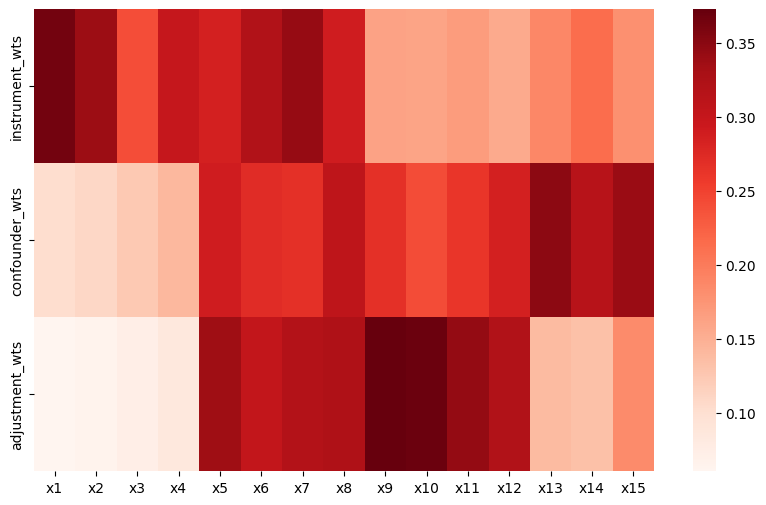

In [13]:
import seaborn as sns
all_latent_wts={"instrument_wts":instrument_wts.detach().numpy(),
                "confounder_wts":confounder_wts.detach().numpy(),
                "adjustment_wts":adjustment_wts.detach().numpy()}
all_latent_wts=pd.DataFrame(all_latent_wts,index=["x1","x2","x3","x4","x5","x6","x7","x8","x9","x10","x11","x12","x13","x14","x15"]).T
plt.rcParams['figure.figsize'] = 10.0, 6.0
sns.heatmap(all_latent_wts,annot_kws={"size":10},cmap="Reds")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

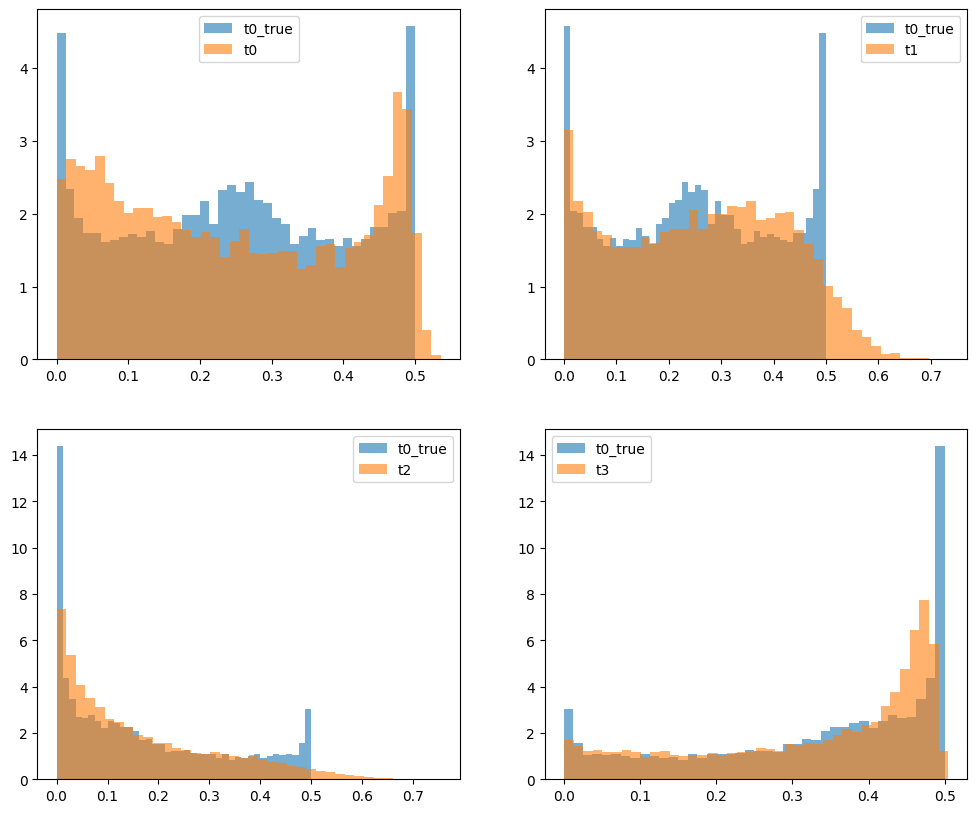

In [14]:
plt.figure(figsize=(12, 10))
plt.subplot(2,2,1)
plt.hist(df_org["propensity0"],bins=40,alpha=0.6,label="t0_true",density=True)
plt.hist(est_t_all[:,0],bins=40,alpha=0.6,label="t0",density=True)
plt.legend()
plt.subplot(2,2,2)
plt.hist(df_org["propensity1"],bins=40,alpha=0.6,label="t0_true",density=True)
plt.hist(est_t_all[:,1],bins=40,alpha=0.6,label="t1",density=True)
plt.legend()
plt.subplot(2,2,3)
plt.hist(df_org["propensity2"],bins=40,alpha=0.6,label="t0_true",density=True)
plt.hist(est_t_all[:,2],bins=40,alpha=0.6,label="t2",density=True)
plt.legend()
plt.subplot(2,2,4)
plt.hist(df_org["propensity3"],bins=40,alpha=0.6,label="t0_true",density=True)
plt.hist(est_t_all[:,3],bins=40,alpha=0.6,label="t3",density=True)
plt.legend()

Text(0.5, 1.0, 'Wasserstein loss')

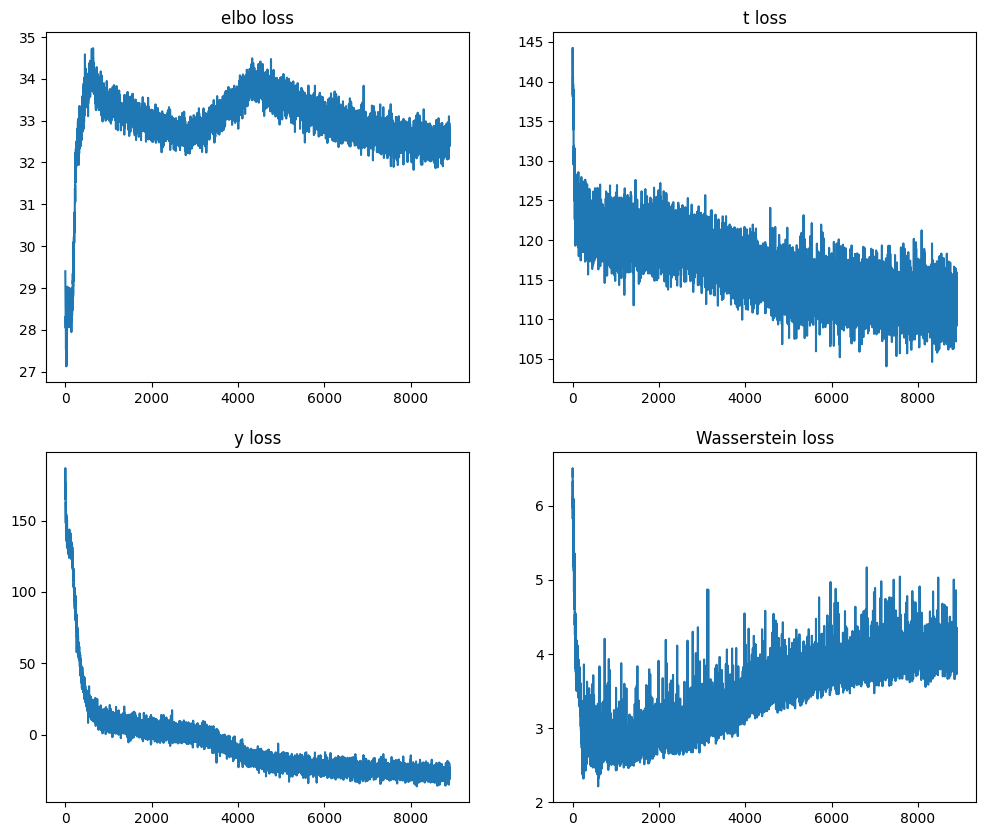

In [15]:
plt.figure(figsize=(12, 10))
plt.subplot(2,2,1)
plt.plot(edvaefit)
plt.title("elbo loss")
plt.subplot(2,2,2)
plt.plot(edvaefit_t)
plt.title("t loss")
plt.subplot(2,2,3)
plt.plot(edvaefit_y)
plt.title("y loss")
plt.subplot(2,2,4)
plt.plot(edvaefit_d)
plt.title("Wasserstein loss")

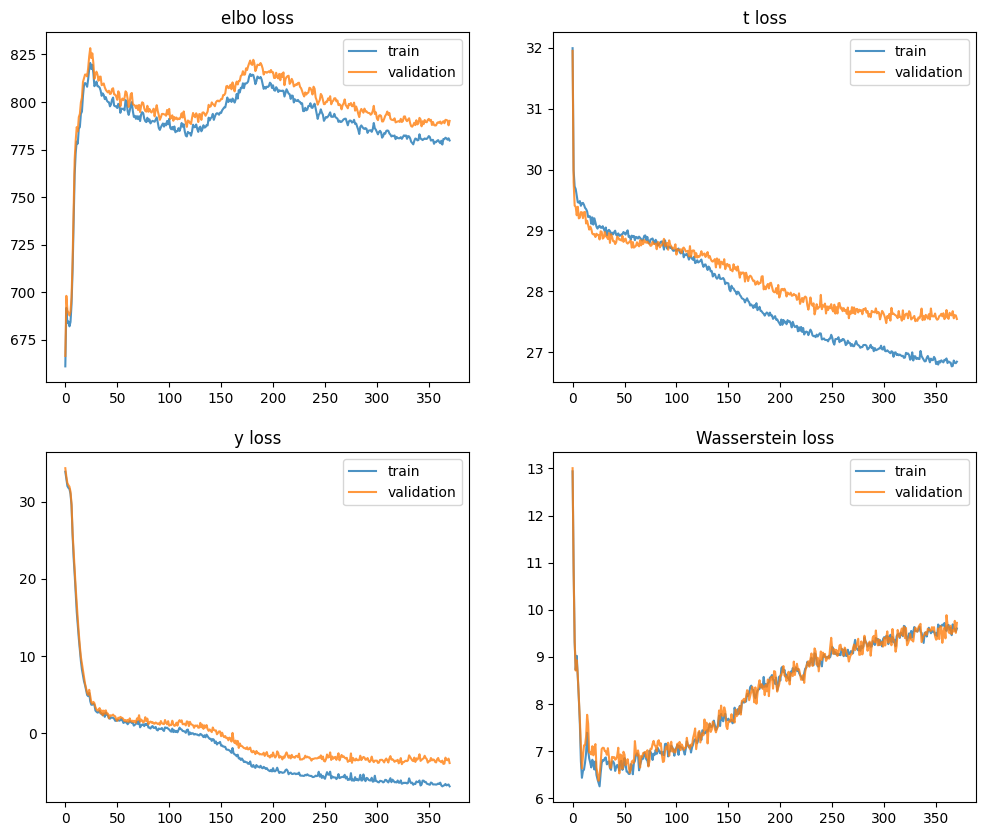

In [16]:
scale_num = x_train.shape[0]/x_valid.shape[0]
plt.figure(figsize=(12, 10))
plt.subplot(2,2,1)
plt.plot(np.array(trn_edvaefit), label = "train", alpha = 0.8)
plt.plot(np.array(val_edvaefit)*scale_num, label = "validation", alpha = 0.8)
plt.title("elbo loss")
plt.legend()
plt.subplot(2,2,2)
plt.plot(np.array(trn_edvaefit_t)/100, label = "train", alpha = 0.8)
plt.plot(np.array(val_edvaefit_t)/100*scale_num, label = "validation", alpha = 0.8)
plt.title("t loss")
plt.legend()
plt.subplot(2,2,3)
plt.plot(np.array(trn_edvaefit_y)/100, label = "train", alpha = 0.8)
plt.plot(np.array(val_edvaefit_y)/100*scale_num, label = "validation", alpha = 0.8)
plt.title("y loss")
plt.legend()
plt.subplot(2,2,4)
plt.plot(np.array(trn_edvaefit_d)/10, label = "train", alpha = 0.8)
plt.plot(np.array(val_edvaefit_d)/10*scale_num, label = "validation", alpha = 0.8)
plt.title("Wasserstein loss")
plt.legend()

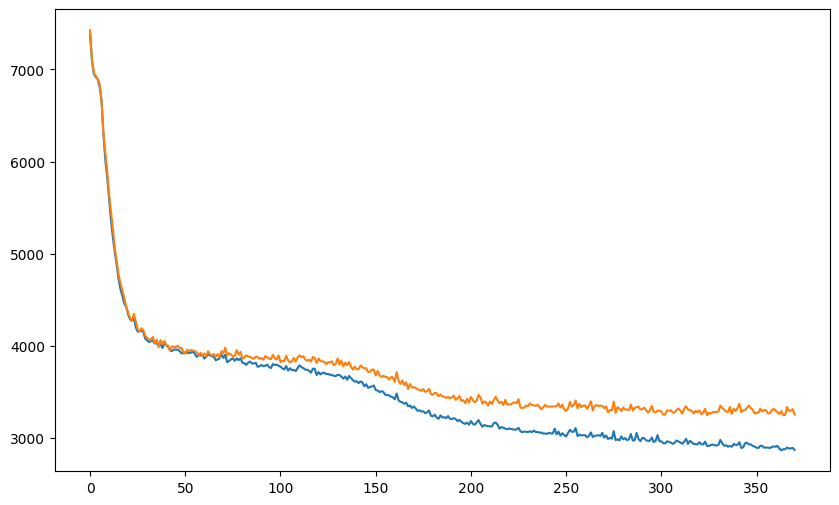

In [17]:
totalloss_tn = np.array(trn_edvaefit) + np.array(trn_edvaefit_t) + np.array(trn_edvaefit_y) + np.array(trn_edvaefit_d)
totalloss_vd = np.array(val_edvaefit) + np.array(val_edvaefit_t) + np.array(val_edvaefit_y) + np.array(val_edvaefit_d)
plt.plot(totalloss_tn)
plt.plot(totalloss_vd*scale_num)

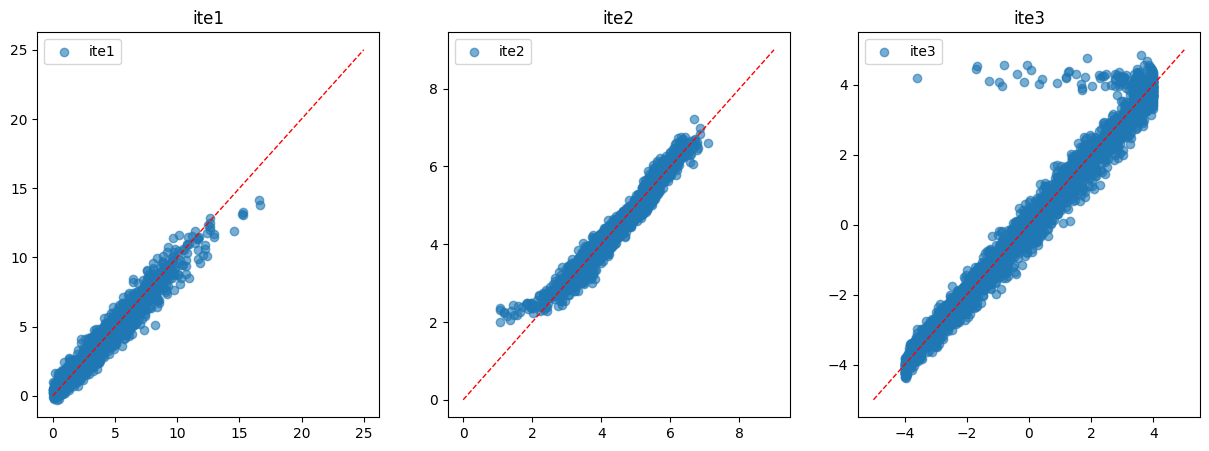

In [18]:
plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.scatter(true_ite_test[:,0].numpy().squeeze(),est_ite1.numpy().squeeze(),alpha=0.6,label="ite1")
plt.plot([0,25],[0,25],color="red",linestyle="--",linewidth=1)
plt.title("ite1")
plt.legend()
plt.subplot(1,3,2)
plt.scatter(true_ite_test[:,1].numpy().squeeze(),est_ite2.numpy().squeeze(),alpha=0.6,label="ite2")
plt.plot([0,9],[0,9],color="red",linestyle="--",linewidth=1)
plt.title("ite2")
plt.legend()
plt.subplot(1,3,3)
plt.scatter(true_ite_test[:,2].numpy().squeeze(),est_ite3.numpy().squeeze(),alpha=0.6,label="ite3")
plt.plot([-5,5],[-5,5],color="red",linestyle="--",linewidth=1)
plt.title("ite3")
plt.legend()

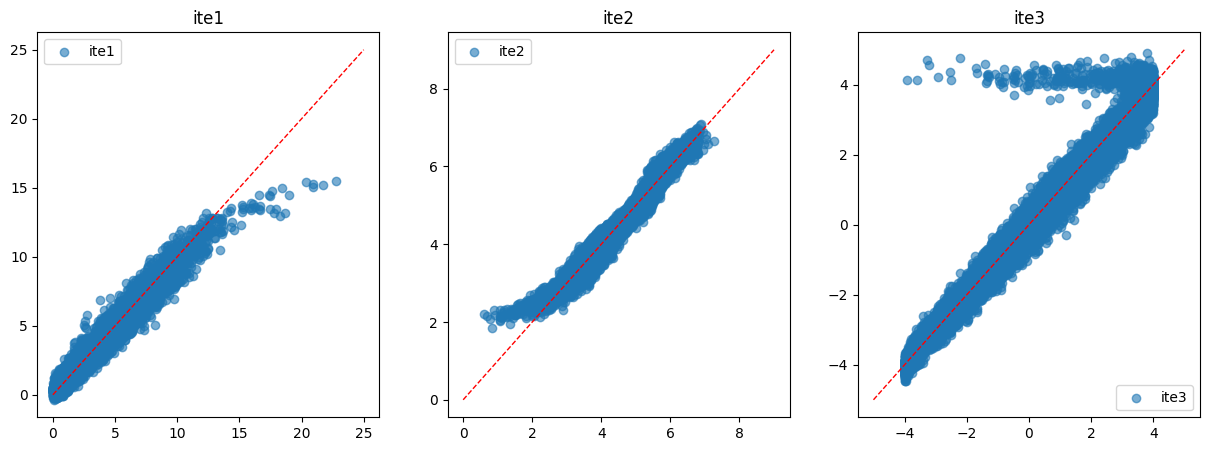

In [19]:
plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.scatter(true_ite[:,0].numpy().squeeze(),est_ite1_all.numpy().squeeze(),alpha=0.6,label="ite1")
plt.plot([0,25],[0,25],color="red",linestyle="--",linewidth=1)
plt.title("ite1")
plt.legend()
plt.subplot(1,3,2)
plt.scatter(true_ite[:,1].numpy().squeeze(),est_ite2_all.numpy().squeeze(),alpha=0.6,label="ite2")
plt.plot([0,9],[0,9],color="red",linestyle="--",linewidth=1)
plt.title("ite2")
plt.legend()
plt.subplot(1,3,3)
plt.scatter(true_ite[:,2].numpy().squeeze(),est_ite3_all.numpy().squeeze(),alpha=0.6,label="ite3")
plt.plot([-5,5],[-5,5],color="red",linestyle="--",linewidth=1)
plt.title("ite3")
plt.legend()

In [20]:
latentt=pd.DataFrame(muzt_hat_all)
latentt.columns=["zt1","zt2","zt3","zt4"]
latentc=pd.DataFrame(muz_hat_all)
latentc.columns=["zc1","zc2","zc3","zc4","zc5","zc6","zc7","zc8"]
latenty=pd.DataFrame(muzy_hat_all)
latenty.columns=["zy1","zy2","zy3"]
latentout=pd.concat([latentt,latentc,latenty],axis=1)
latentout.to_csv("C:/Users/ASUS/Desktop/cg working/Variational autoencoder/vae_compare/edvae_latentout.csv")

In [21]:
est_ite1_tr,est_ite2_tr,est_ite3_tr,est_y0_tr,est_y1_tr,est_y2_tr,est_y3_tr,est_t_tr,muz_hat_tr,muzt_hat_tr,muzy_hat_tr,\
    ite_gen_tr,t_gen_tr,y0gen_tr,y1gen_tr,TC_list_tr = edvae.ite(x_train, ym, ys)

In [22]:
tt=t.numpy().squeeze()
est_tt_all=est_t_all.numpy()
yy0=est_y0_all.detach().numpy()
yy1=est_y1_all.detach().numpy()
yy2=est_y2_all.detach().numpy()
yy3=est_y3_all.detach().numpy()
yy=y
yy=yy.numpy().squeeze()
ITE01=est_ite1_all.numpy()
ITE02=est_ite2_all.numpy()
ITE03=est_ite3_all.numpy()

resultdata={"mu0":yy0,
            "mu1":yy1,
            "mu2":yy2,
            "mu3":yy3,
            "edvae_ite01":ITE01,
            "edvae_ite02":ITE02,
            "edvae_ite03":ITE03,
            "propensity_hat0":est_tt_all[:,0],
            "propensity_hat1":est_tt_all[:,1],
            "propensity_hat2":est_tt_all[:,2],
            "propensity_hat3":est_tt_all[:,3]}
resultdata=pd.DataFrame(resultdata)
output=pd.concat([df.reset_index(drop=True),resultdata],axis=1)
output.to_csv("C:/Users/ASUS/Desktop/cg working/Variational autoencoder/vae_compare/edvae_to_metalearner_output_mclass.csv")

In [23]:
output

,outcome,ite1,ite2,ite3,Treat_0,Treat_1,Treat_2,Treat_3,X1,X2,...,mu1,mu2,mu3,edvae_ite01,edvae_ite02,edvae_ite03,propensity_hat0,propensity_hat1,propensity_hat2,propensity_hat3
0,6.918691,2.914008,4.010017,-2.420075,0,1,0,0,0.498996,-0.744683,...,7.093904,8.715958,2.184712,2.216520,3.838574,-2.692672,0.013320,0.520407,0.003750,0.462523
1,1.173079,2.453375,3.749346,-2.910310,0,0,0,1,-0.125312,-0.518729,...,6.755229,7.959105,1.319176,2.676880,3.880754,-2.759174,0.220987,0.275610,0.108485,0.394918
2,3.366261,1.649285,3.170725,-3.587291,1,0,0,0,0.624574,-0.547371,...,4.915044,6.330654,-0.457278,1.708517,3.124126,-3.663805,0.440897,0.093859,0.289641,0.175603
3,12.798639,0.418414,4.391668,-1.431199,0,0,1,0,-0.600122,0.155275,...,9.217270,13.430288,7.546457,0.289929,4.502948,-1.380884,0.380341,0.133416,0.263430,0.222812
4,0.561499,2.219805,2.841679,-3.792347,1,0,0,0,0.221132,-1.266828,...,4.010106,5.114202,-1.459315,1.655837,2.759934,-3.813583,0.483940,0.042887,0.384713,0.088460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,12.393551,2.591584,5.150184,1.512360,0,0,0,1,-0.234931,-1.451077,...,13.197474,15.578890,11.970734,2.573861,4.955276,1.347121,0.028723,0.482273,0.008823,0.480181
14996,17.175965,9.085179,5.668606,3.554392,0,1,0,0,0.221643,-2.370786,...,17.387756,13.723584,11.046286,9.597698,5.933528,3.256228,0.029496,0.497202,0.008092,0.465211
14997,10.000931,8.130253,4.882374,0.353477,0,0,1,0,2.204203,-1.486085,...,11.797212,8.891150,4.513870,7.711658,4.805596,0.428317,0.474307,0.087701,0.285378,0.152613
14998,8.008183,0.222622,2.851502,-3.787606,0,0,1,0,0.108406,0.818902,...,3.994047,6.791422,0.200405,0.228259,3.025635,-3.565383,0.298034,0.203419,0.170562,0.327985


--------------------------------------------------------------------------------------------------------------------------------------------------------

'hidden_dim': 24,'num_layers': 4

In [24]:
#ite 1
pehe_train = np.sqrt(np.mean((true_ite_train[:,0].numpy().squeeze()-est_ite1_tr.numpy().squeeze())**2))
pehe_test = np.sqrt(np.mean((true_ite_test[:,0].numpy().squeeze()-est_ite1.numpy().squeeze())**2))
pehe_all = np.sqrt(np.mean((true_ite[:,0].numpy().squeeze()-est_ite1_all.numpy().squeeze())**2))
print("ite1")
print(f"Train:  {pehe_train}")
print(f"Test:  {pehe_test}")
print(f"ALL data:  {pehe_all}")
print(f"True ATE:  {true_ite[:,0].mean()}")
print(f"pred ATE:  {est_ite1_all.mean()}")
print(abs(true_ite[:,0].mean()-est_ite1_all.mean()))
print("")

#ite 2
pehe_train = np.sqrt(np.mean((true_ite_train[:,1].numpy().squeeze()-est_ite2_tr.numpy().squeeze())**2))
pehe_test = np.sqrt(np.mean((true_ite_test[:,1].numpy().squeeze()-est_ite2.numpy().squeeze())**2))
pehe_all = np.sqrt(np.mean((true_ite[:,1].numpy().squeeze()-est_ite2_all.numpy().squeeze())**2))
print("ite2")
print(f"Train:  {pehe_train}")
print(f"Test:  {pehe_test}")
print(f"ALL data:  {pehe_all}")
print(f"True ATE:  {true_ite[:,1].mean()}")
print(f"pred ATE:  {est_ite2_all.mean()}")
print(abs(true_ite[:,1].mean()-est_ite2_all.mean()))
print("")

#ite 3
pehe_train = np.sqrt(np.mean((true_ite_train[:,2].numpy().squeeze()-est_ite3_tr.numpy().squeeze())**2))
pehe_test = np.sqrt(np.mean((true_ite_test[:,2].numpy().squeeze()-est_ite3.numpy().squeeze())**2))
pehe_all = np.sqrt(np.mean((true_ite[:,2].numpy().squeeze()-est_ite3_all.numpy().squeeze())**2))
print("ite3")
print(f"Train:  {pehe_train}")
print(f"Test:  {pehe_test}")
print(f"ALL data:  {pehe_all}")
print(f"True ATE:  {true_ite[:,2].mean()}")
print(f"pred ATE:  {est_ite3_all.mean()}")
print(abs(true_ite[:,2].mean()-est_ite3_all.mean()))
print("")

ite1
Train:  0.5159695148468018
Test:  0.517242968082428
ALL data:  0.5185362100601196
True ATE:  3.0264453887939453
pred ATE:  2.954791784286499
tensor(0.0717)

ite2
Train:  0.18652178347110748
Test:  0.18818442523479462
ALL data:  0.1862083226442337
True ATE:  4.6050639152526855
pred ATE:  4.590531349182129
tensor(0.0145)

ite3
Train:  0.5087113380432129
Test:  0.5012134313583374
ALL data:  0.49719002842903137
True ATE:  -0.23597867786884308
pred ATE:  -0.20649123191833496
tensor(0.0295)



In [25]:
from sklearn.metrics import accuracy_score
a=est_t_all[:,0].numpy().copy()
a[(est_t_all[:,0]>0.5).numpy()]=1
a[(est_t_all[:,0]<=0.5).numpy()]=0
a_tr=est_t_tr[:,0].numpy().copy()
a_tr[(est_t_tr[:,0]>0.5)]=1
a_tr[(est_t_tr[:,0]<=0.5)]=0
a_ts=est_t[:,0].numpy().copy()
a_ts[(est_t[:,0]>0.5).numpy()]=1
a_ts[(est_t[:,0]<=0.5).numpy()]=0

print("Treat_0")
print(f"accuracy_Train:  {accuracy_score(np.array(t_train[:,0]),a_tr)}")
print(f"accuracy_Test:  {accuracy_score(np.array(t_test[:,0]),a_ts)}")
print(f"accuracy_all:  {accuracy_score(np.array(df["Treat_0"]),a)}")
print("")

a=est_t_all[:,1].numpy().copy()
a[(est_t_all[:,1]>0.5).numpy()]=1
a[(est_t_all[:,1]<=0.5).numpy()]=0
a_tr=est_t_tr[:,1].numpy().copy()
a_tr[(est_t_tr[:,1]>0.5)]=1
a_tr[(est_t_tr[:,1]<=0.5)]=0
a_ts=est_t[:,1].numpy().copy()
a_ts[(est_t[:,1]>0.5).numpy()]=1
a_ts[(est_t[:,1]<=0.5).numpy()]=0

print("Treat_1")
print(f"accuracy_Train:  {accuracy_score(np.array(t_train[:,1]),a_tr)}")
print(f"accuracy_Test:  {accuracy_score(np.array(t_test[:,1]),a_ts)}")
print(f"accuracy_all:  {accuracy_score(np.array(df["Treat_1"]),a)}")
print("")

a=est_t_all[:,2].numpy().copy()
a[(est_t_all[:,2]>0.5).numpy()]=1
a[(est_t_all[:,2]<=0.5).numpy()]=0
a_tr=est_t_tr[:,2].numpy().copy()
a_tr[(est_t_tr[:,2]>0.5)]=1
a_tr[(est_t_tr[:,2]<=0.5)]=0
a_ts=est_t[:,2].numpy().copy()
a_ts[(est_t[:,2]>0.5).numpy()]=1
a_ts[(est_t[:,2]<=0.5).numpy()]=0

print("Treat_2")
print(f"accuracy_Train:  {accuracy_score(np.array(t_train[:,2]),a_tr)}")
print(f"accuracy_Test:  {accuracy_score(np.array(t_test[:,2]),a_ts)}")
print(f"accuracy_all:  {accuracy_score(np.array(df["Treat_2"]),a)}")
print("")

a=est_t_all[:,3].numpy().copy()
a[(est_t_all[:,3]>0.5).numpy()]=1
a[(est_t_all[:,3]<=0.5).numpy()]=0
a_tr=est_t_tr[:,3].numpy().copy()
a_tr[(est_t_tr[:,3]>0.5)]=1
a_tr[(est_t_tr[:,3]<=0.5)]=0
a_ts=est_t[:,3].numpy().copy()
a_ts[(est_t[:,3]>0.5).numpy()]=1
a_ts[(est_t[:,3]<=0.5).numpy()]=0

print("Treat_3")
print(f"accuracy_Train:  {accuracy_score(np.array(t_train[:,3]),a_tr)}")
print(f"accuracy_Test:  {accuracy_score(np.array(t_test[:,3]),a_ts)}")
print(f"accuracy_all:  {accuracy_score(np.array(df["Treat_3"]),a)}")
print("")

Treat_0
accuracy_Train:  0.7529166666666667
accuracy_Test:  0.753
accuracy_all:  0.7522666666666666

Treat_1
accuracy_Train:  0.7460416666666667
accuracy_Test:  0.757
accuracy_all:  0.7467333333333334

Treat_2
accuracy_Train:  0.8336458333333333
accuracy_Test:  0.8273333333333334
accuracy_all:  0.8332

Treat_3
accuracy_Train:  0.6739583333333333
accuracy_Test:  0.6586666666666666
accuracy_all:  0.6721333333333334



In [26]:
b = est_y3_all.numpy()*np.array(df["Treat_3"])+est_y2_all.numpy()*np.array(df["Treat_2"])+\
    est_y1_all.numpy()*np.array(df["Treat_1"])+est_y0_all.numpy()*np.array(df["Treat_0"])
b_tr = est_y3_tr.numpy()*np.array(t_train[:,3])+est_y2_tr.numpy()*np.array(t_train[:,2])+\
       est_y1_tr.numpy()*np.array(t_train[:,1])+est_y0_tr.numpy()*np.array(t_train[:,0])
b_ts = est_y3.numpy()*np.array(t_test[:,3])+est_y2.numpy()*np.array(t_test[:,2])+\
       est_y1.numpy()*np.array(t_test[:,1])+est_y0.numpy()*np.array(t_test[:,0])

print(f"mse_Train:  {np.sqrt(np.mean((np.array(y_train*ys+ym)-b_tr)**2))}")
print(f"mse_Test:  {np.sqrt(np.mean((np.array(y_test*ys+ym)-b_ts)**2))}")
print(f"mse_all:  {np.sqrt(np.mean((np.array(df["outcome"])-b)**2))}")

mse_Train:  1.0047286748886108
mse_Test:  1.1227167844772339
mse_all:  1.0250499813524543


In [27]:
# pyro.set_rng_seed(241014)
# z,zt,zy = edvae.guide.z_mean(X)
# Zt=pd.DataFrame(zt.detach().numpy())
# Zt.columns=["zt1","zt2"]
# Zc=pd.DataFrame(z.detach().numpy())
# Zc.columns=["zc1","zc2","zc3"]
# Zy=pd.DataFrame(zy.detach().numpy())
# Zy.columns=["zy1","zy2","zy3","zy4","zy5"]
# Zout=pd.concat([Zt,Zc,Zy],axis=1)
# Zout.to_csv("C:/Users/ASUS/Desktop/cg working/Variational autoencoder/vae_compare/edvae_Zout.csv")

--------------------------------------------------------------------------------------------------------------------------------------------------------